In [31]:
#%pip install pandas numpy matplotlib

**LIBRARIES**

In [32]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

**ANALYSIS**

In [33]:
class Himmelblau:
    def __init__(self):
        self.name   = "Himmelblau"
        self.minima = [(3, 2), (-2.805, 3.131), (-3.779, -3.283), (3.584, -1.848)]
        self.limits = [(-6, 6), (-6, 6)]

    def evaluate(self, x, y):
        return (x**2 + y - 11)**2 + (x + y**2 - 7)**2
    

In [34]:
#def himmelblau(x, y):
#    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

In [35]:
def lectura(filepath: str):
    # 1. Cargar datos 
    # Leemos el archivo detectando automáticamente el separador (puede ser coma, punto y coma, tabulación, etc.)
    df = pd.read_csv(filepath, sep=None, engine='python')

    # Limpiamos nombres de columnas (quita espacios invisibles como " X" -> "X")
    df.columns = df.columns.str.strip()
    print(f"Columnas detectadas: {list(df.columns)}")

    # 3. Extraer valores de la columna 2 (X) y de la columna 3(Y) (Usando .iloc es más seguro si las columnas son la 2 y la 3)
    val_x = df.iloc[:, 1] # iloc[:, 1] es la segunda columna donde estan los valores de X
    val_y = df.iloc[:, 2] # iloc[:, 2] es la tercera columna donde estan los valores de Y

    return val_x, val_y, df

In [36]:
def plot_himmelblau(val_x, val_y, round: str): #, save_figure: bool = False): 

    function = Himmelblau()

    ###-PLOT-###
    # 1. Crear el fondo de la función
    x_range = np.linspace(-6, 6, 400)
    y_range = np.linspace(-6, 6, 400)
    X_mesh, Y_mesh = np.meshgrid(x_range, y_range)
    Z_mesh = function.evaluate(X_mesh, Y_mesh)

    # 2. Dibujar el mapa
    plt.figure(figsize=(10, 7))
    plt.contourf(X_mesh, Y_mesh, Z_mesh, levels=np.logspace(0, 5, 35), norm=LogNorm(), cmap='viridis', alpha=0.7)
    plt.colorbar(label='Himmelblau value')

    # 3. Dibujar TUS puntos (usando el df que ya tienes en memoria)
    plt.scatter(val_x, val_y, color='red', edgecolors='white', s=80, label='Explored points')

    # Añadir etiquetas de número de RUN
    #for i, row in df.iterrows():
    #    plt.text(row.iloc[1]+0.1, row.iloc[2]+0.1, str(int(row.iloc[0])), color='white', fontsize=9)

    plt.title(f"Round {round}")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()

    return plt

    if save_figure:
        plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    plt.show()

In [37]:
## Parametres:
save_plot = False

------------------------------
Procesando archivo: Himmelblau_R0.csv
Guardando Output en Himmelblau_R0_RESULTADO.csv
Guardando Gráfico en Himmelblau_R0_plot.jpg
Round: 0
------------------------------
Columnas detectadas: ['RUN', 'X', 'Y']
   RUN     X        Y          R0
0    1  1.02  0.60000  119.186512
1    2  1.08  6.00000  919.502889
2    3 -3.00  1.86000   42.796432
3    4 -6.00 -1.20000  700.073600
4    5 -6.00 -5.23437  598.000655
------------------------------
Procesando archivo: Himmelblau_R1.csv
Guardando Output en Himmelblau_R1_RESULTADO.csv
Guardando Gráfico en Himmelblau_R1_plot.jpg
Round: 1
------------------------------
Columnas detectadas: ['Number', 'X', 'Y', 'R1']
   Number      X      Y        R1          R0
0       1 -3.112  1.389  -138.447   66.961644
1       2 -0.423 -4.576   -98.111  419.773029
2       3  0.420 -2.480  -691.826  177.170329
3       4 -3.600 -2.400 -1457.100   23.619200
4       5  5.850 -0.884   -19.032  499.144407
------------------------------


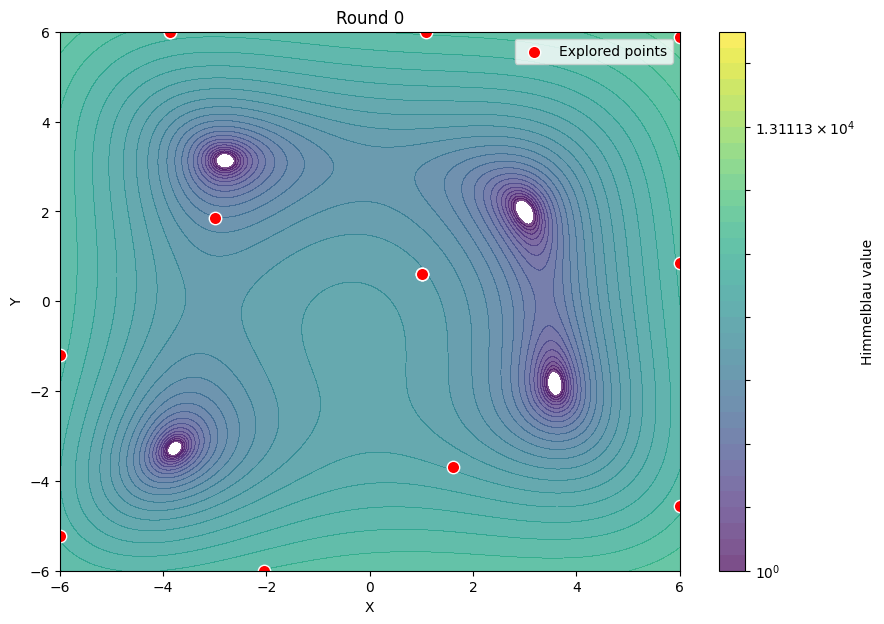

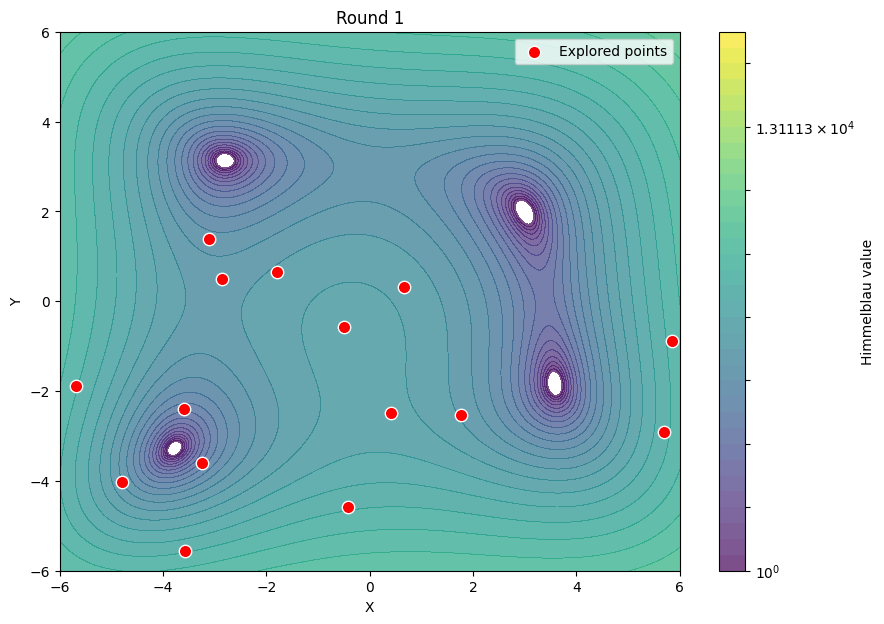

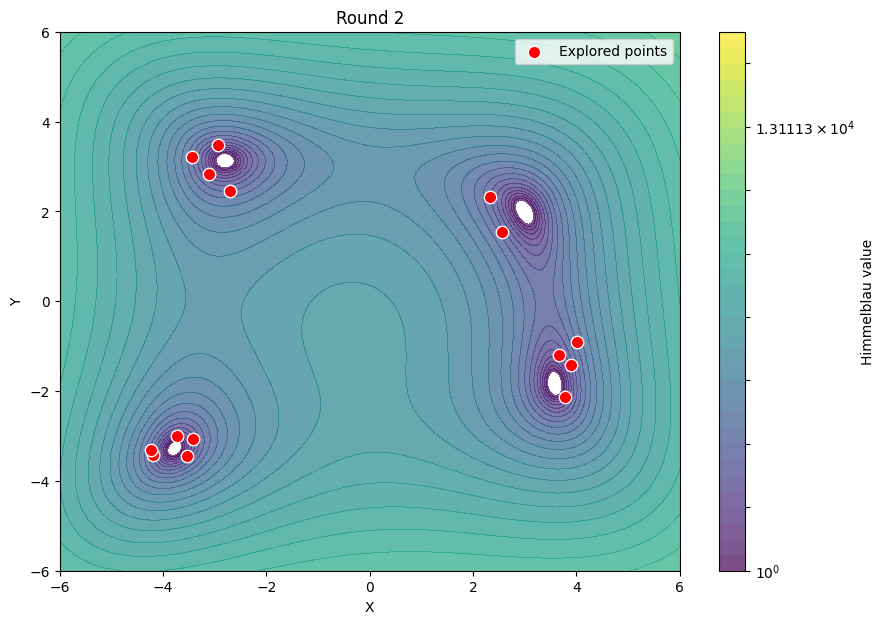

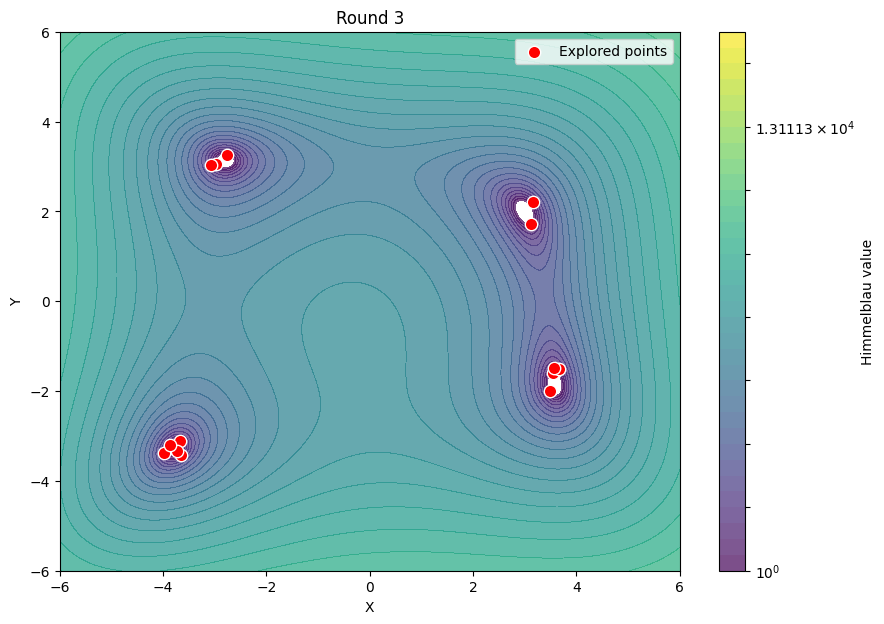

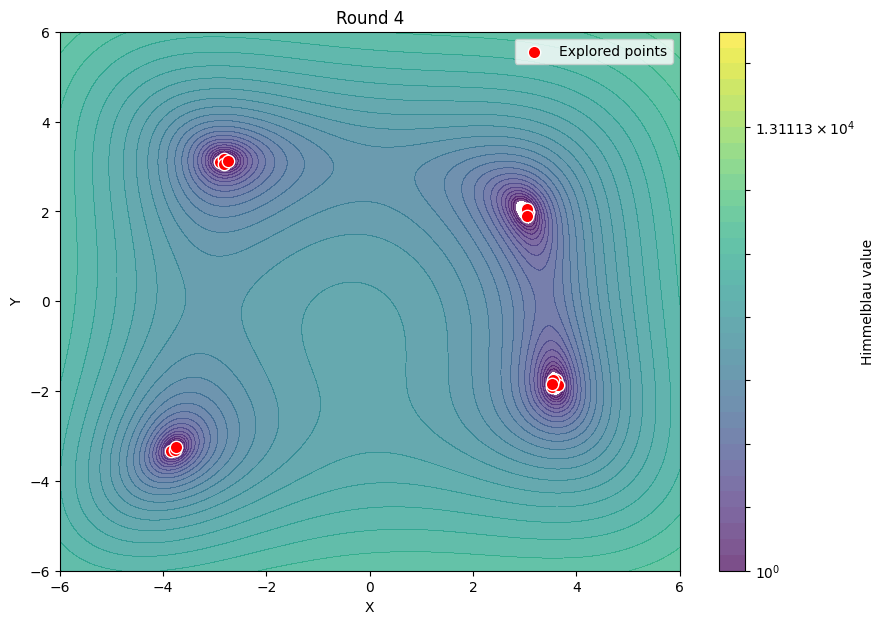

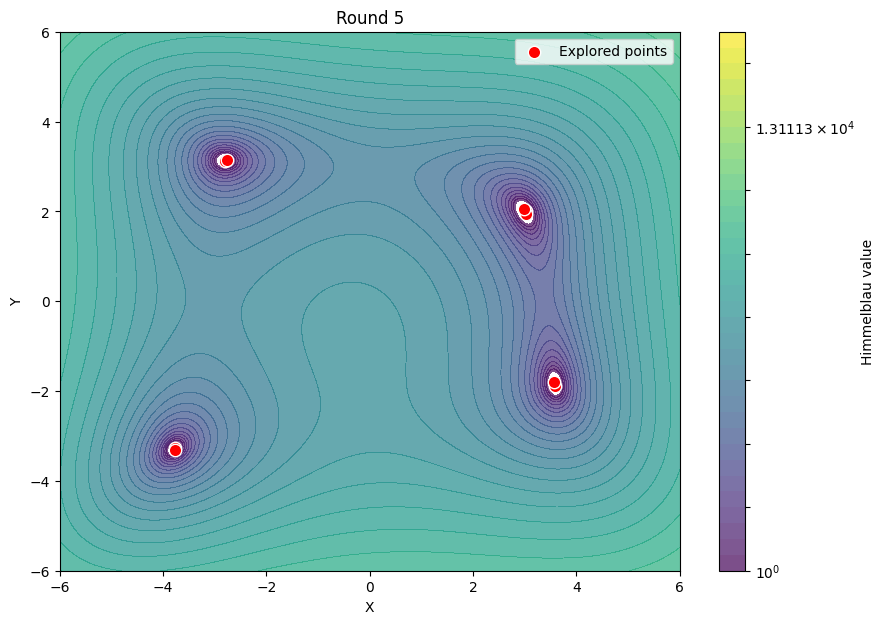

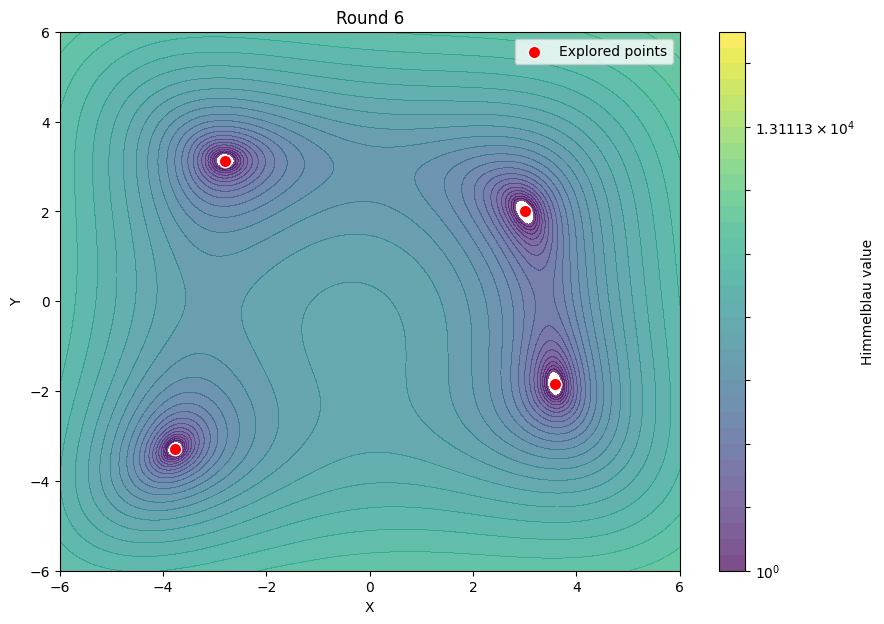

In [38]:
function = Himmelblau()
csvs = [f for f in os.listdir("C:\\Users\\Usuario\\Documents\\TFM-MELINA\\Himmelblau") if f.endswith('.csv') and f.startswith('Himmelblau') and "RESULTADO" not in f and "plot" not in f]

for file in csvs:
    output_file = file.replace('.csv', '_RESULTADO.csv')
    plot_file   = file.replace('.csv', '_plot.jpg')
    round       = int(file.split('_')[-1].replace('.csv', '').replace('R', '')) # Extrae el número de round del nombre del archivo

    print("-" * 30)
    print(f"Procesando archivo: {file}")
    print(f"Guardando Output en {output_file}")
    print(f"Guardando Gráfico en {plot_file}")
    print(f"Round: {round}")
    print("-" * 30)

    val_x, val_y, df = lectura(file)

    # 4. Calcular el resultado y gua1rdarlo en la nueva columna 4 (indice 3)
    df['R0'] = function.evaluate(val_x, val_y)

    # 5. Guardar el archivo actualizado en el Escritorio
    df.to_csv(output_file, index=False)

    print(df.head()) # Mostrar los primeros resultados para verificar
    plt = plot_himmelblau(val_x, val_y, str(round))
    
    if save_plot:
        plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        print(f"Gráfico guardado correctamente como :{plot_file}")

